# Line Search Methods

In this section, we'll look at methods to approximately solve the one dimensional minimization problem

\begin{equation*}
\min_{\alpha} \phi(\alpha)
\end{equation*}

where $\phi(\alpha) : \mathbb{R} \rightarrow \mathbb{R}$.

The function $\phi(\alpha)$ will often arise from a line search embedded within a line search optimziation algorithm. The purpose of these line searches will be to guarantee that sufficient progress is made towards a minimizer of a function $f(x) : \mathbb{R}^{n} \rightarrow \mathbb{R}$. In these cases, the *line search function*, or *merit function*, is generated based on a search direction $p \in \mathbb{R}^{n}$ from the current point $x \in \mathbb{R}^{n}$ in the design space. For these applications, the merit function can be written as

\begin{equation*}
\phi(\alpha) = f(x + \alpha p)
\end{equation*}

where $x$ and $p$ are fixed.

A key requirement of the line search metohd is that the derivative at $\alpha = 0$ must be negative such that $\phi'(0) < 0$.
Here, $\phi'(\alpha)$ denotes the derivative of $\phi(\alpha)$ with respect to $\alpha$. For a merit function, this derivative is related to the objective function as

\begin{equation*}
\phi'(\alpha) = \frac{d f(x + \alpha p)}{d \alpha} = \nabla f(x + \alpha p)^{T} p
\end{equation*}

At $\alpha = 0$, this means that $\phi'(0) = \nabla f(x)^{T} p$.

## Interactive Line Search for the Rosenbrock Function

The following applet can be used to visualize the construction of the line search function according to the dependence on the initial point and search direction. Here, the function of interest is the Rosenbrock function, shown below, with the parameters $a=1$ and $b=2$. 

\begin{equation*}
f(x_1, x_2) = (a-x_1)^2 + b(x_2-x_1^2)^2
\end{equation*}

To interact with the applet, you can drag the initial point $x_0$ around in the top-left pane and change the search direction inputs for $p_x$ and $p_y$. As these are varied, the line search function in the bottom-left pane will automatically update. 


In [1]:
from IPython.display import HTML

html_code = """
<script src="https://www.geogebra.org/apps/deployggb.js"></script>
<script>
var params = {"material_id": "yyrannp2", "showFullScreenButton": true};
var applet = new GGBApplet(params, true);
window.addEventListener("load", function() {
    applet.inject('ggb-element');
});
</script>
<div id="ggb-element"></div>
"""

HTML(html_code)


## Example: 1D line search

Consider a line search for the 1D function

\begin{equation*}
f(x) = x^2(1 + x)^2
\end{equation*}

from the points $x_{0} = 1$ and $x_{0} = -1/4$. The derivative of the function is

\begin{equation*}
f'(x) = 2x(1 + x)^2 + 2x^2(1 + x)
\end{equation*}

At the point $x_{0} = 1$, we have $f(1) = 4$ and $f'(1) = 12$. We need to choose $p \in \mathbb{R}$ such that f'(1)p < 0.

- For $p = -\dfrac{f'(1)}{|f'(1)|} = -1$

\begin{equation*}
\phi(\alpha) = f(x_{0} + \alpha p) = f(1 - \alpha) = (1 - \alpha)^2 (2 - \alpha)^2 
\end{equation*}

- For $p = -f'(1) = -12$

\begin{equation*}
\phi(\alpha) = f(x_{0} + \alpha p) = f(1 - 12\alpha) = (1 - 12\alpha)^2 (2 - 12\alpha)^2 
\end{equation*}

At the point $x_{0} = -1/4$, $f(-1/4) = 9/256$, $f'(-1/4) = -3/16$, so we have to choose $p > 0$ for the line search.

- For $p = -\dfrac{f'(x)}{|f'(x)|} = 1$

\begin{equation*}
\phi(\alpha) = f(-1/4 + \alpha) = \frac{1}{256} (4\alpha - 1)^2 (3 + \alpha)^2 
\end{equation*}

- For $p = -f'(x) = 3/16$

\begin{equation*}
\phi(\alpha) = f(-1/4 + 3/16\alpha) = (-1/4 + 3/16\alpha)^2 (3/4 + 3/16\alpha)^2 
\end{equation*}

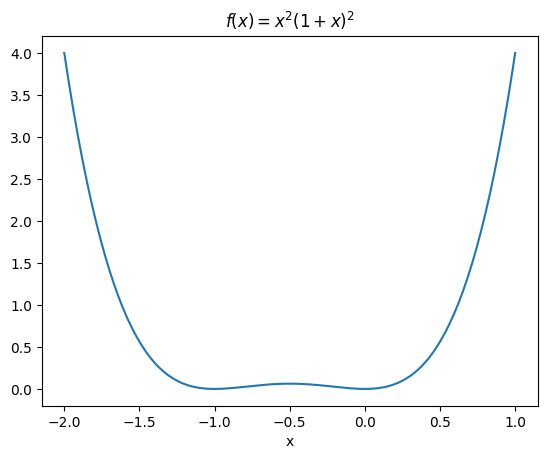

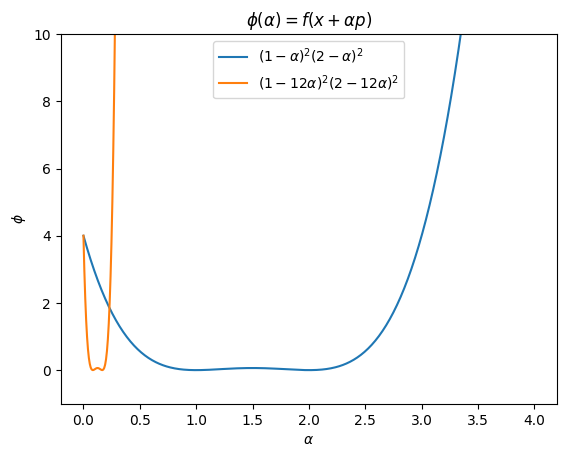

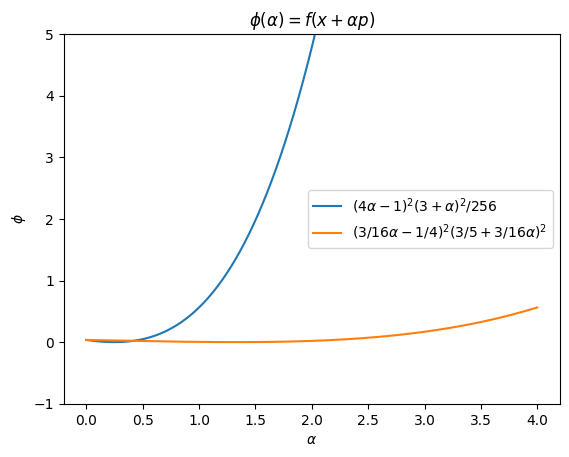

In [2]:
import numpy as np
import matplotlib.pyplot as plt

n = 200
x = np.linspace(-2, 1, n)
plt.figure()
plt.plot(x, x**2*(1 + x)**2)
plt.title('$f(x) = x^2 (1 + x)^2$')
plt.xlabel('x')

n = 500
a = np.linspace(0, 4, n)
plt.figure()
plt.title(r'$\phi(\alpha) = f(x + \alpha p)$')
plt.plot(a, (1 - a)**2*(2 - a)**2,
         label=r'$(1 - \alpha)^2 (2 - \alpha)^2$')
plt.plot(a, (1 - 12*a)**2*(2 - 12*a)**2,
         label=r'$(1 - 12\alpha)^2 (2 - 12\alpha)^2$')
plt.xlabel(r'$\alpha$')
plt.ylabel(r'$\phi$')
plt.ylim(-1, 10)
plt.legend()

plt.figure()
plt.title(r'$\phi(\alpha) = f(x + \alpha p)$')
plt.plot(a, ((4*a - 1)**2*(3 + a)**2)/256.0, 
         label=r'$(4\alpha - 1)^2 (3 + \alpha)^2/256$')
plt.plot(a, (-0.25 + (3.0/16)*a)**2*(0.75 + (3.0/16)*a)**2, 
         label=r'$(3/16\alpha -1/4)^2 (3/5 + 3/16\alpha)^2$')
plt.xlabel(r'$\alpha$')
plt.ylabel(r'$\phi$')
plt.legend()
plt.ylim(-1, 5)

plt.show()

## Example: Rosenbrock function

The Rosenbrock function is frequently used as an optimization example problem in unconstrained and constrained optimization.
The function is defined as

\begin{equation*}
f(x_{1}, x_{2}) = (1 - x_{1})^2 + 100(x_{2} - x_{1}^2)^2
\end{equation*}

From the point 
\begin{equation*}
x_{0} = \begin{bmatrix} -1 \\ -1\end{bmatrix}
\end{equation*}

Consider the search directions
\begin{equation*}
p = \begin{bmatrix} 1 \\ 1 \end{bmatrix} \qquad
p = \begin{bmatrix} 1/2 \\ 1 \end{bmatrix} \qquad
p = \begin{bmatrix} 1 \\ 1/2 \end{bmatrix}
\end{equation*}

For the direction $(1, 1)$:
\begin{equation*}
x(\alpha) = x_{0} + \alpha p
= \begin{bmatrix} -1 \\ -1 \end{bmatrix} + 
\alpha \begin{bmatrix} 1 \\ 1 \end{bmatrix} 
= \begin{bmatrix} \alpha -1 \\ \alpha-1 \end{bmatrix}
\end{equation*}

\begin{equation*}
\begin{aligned}
\phi(\alpha) &= f(\alpha-1, \alpha-1) \\
&= (2 - \alpha)^2 + 100(\alpha-1 - (\alpha -1)^2)^2 
\end{aligned}
\end{equation*}

\begin{equation*}
\begin{aligned}
\phi'(\alpha) &= - 2(2 - \alpha) + 200(\alpha-1 - (\alpha -1)^2)(1 - 2(\alpha-1)) \\
&= -1204 + 2602 \alpha - 1800 \alpha^2 + 400 \alpha^3
\end{aligned}
\end{equation*}

- $\alpha = 2$ is the global minima, $\alpha = (20 - \sqrt{23})/20$ is a local minima, and $\alpha = (20 + \sqrt{23})/20$ is a local maxima

The following code illustrates these search directions for a number of functions of interest in 2D.

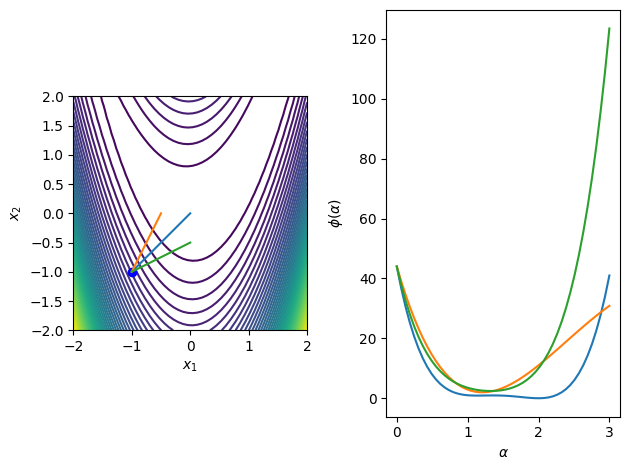

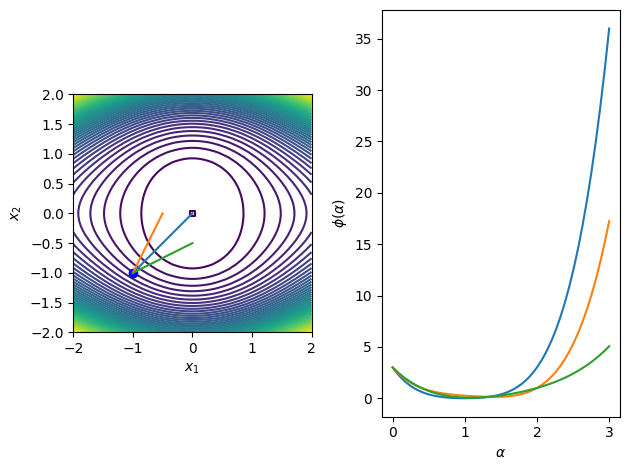

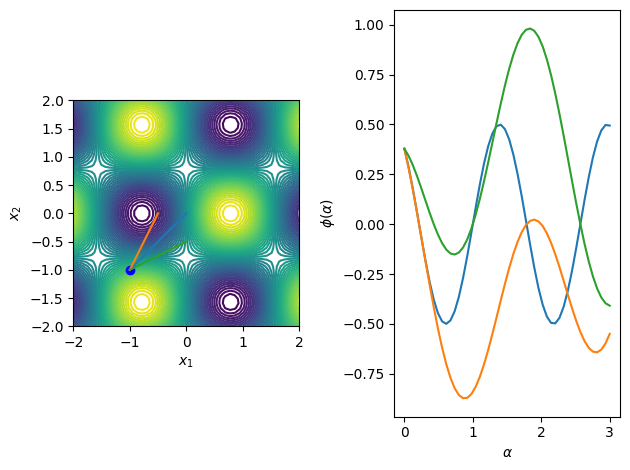

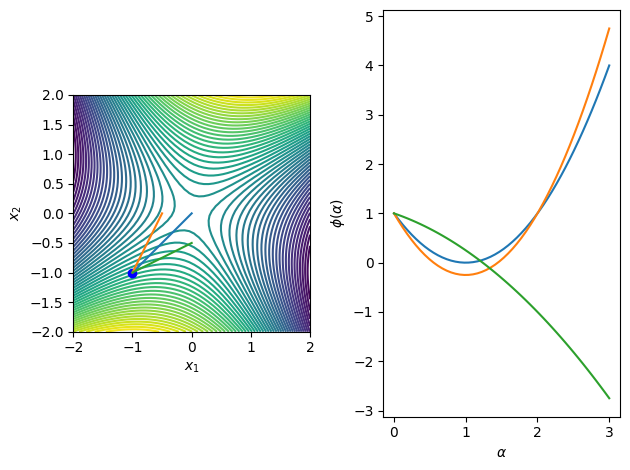

In [3]:
import numpy as np
import matplotlib.pylab as plt

def merit_func_plot(fobj, x0, dirs):
    # Generate the data for a contour plot
    n = 50
    x1 = np.linspace(-2, 2, n)
    x2 = np.linspace(-2, 2, n)
    X1, X2 = np.meshgrid(x1, x2)
    f = np.zeros((n, n))

    # Query the function at the specified locations
    for i in range(n):
        for j in range(n):
            f[i, j] = fobj([X1[i, j], X2[i, j]])

    fig, ax = plt.subplots(1, 2)
    ax[0].contour(X1, X2, f, levels=np.linspace(np.min(f), np.max(f)))
    ax[0].plot([x0[0]], [x0[1]], 'bo')
    ax[0].set_aspect('equal', 'box')
    ax[0].set_xlabel(r'$x_{1}$')
    ax[0].set_ylabel(r'$x_{2}$')
    ax[1].set_xlabel(r'$\alpha$')
    ax[1].set_ylabel(r'$\phi(\alpha)$')
    
    # Plot the directions on the contour plot
    for p in dirs:
        m = 50
        alpha = np.linspace(0, 3, m)
        fvals = np.zeros(m)
        for i, alph in enumerate(alpha):
            fvals[i] = fobj(x0 + alph*p)
        
        ax[0].plot([x0[0], x0[0] + p[0]],
                   [x0[1], x0[1] + p[1]])
        ax[1].plot(alpha, fvals)
    
    fig.tight_layout()

    return

def f1(x):
    return (1 - x[0])**2 + 10*(x[1] - x[0]**2)**2

def f2(x):
    return x[0]**2 + x[0]**2*x[1]**2 + x[1]**4

def f3(x):
    return np.sin(2*x[0])*np.cos(2*x[1])

def f4(x):
    return -x[0]**2 + x[0]*x[1] + x[1]**2

x0 = np.array([-1, -1])
dirs = np.array([[1, 1], [0.5, 1], [1, 0.5]])

for fobj in [f1, f2, f3, f4]:
    merit_func_plot(fobj, x0, dirs)



## Exact minimizers for line searches

In some special cases it is possible to efficiently find the exact minimizer of a line search. 
Usually we'll be satisfied with an approximate solution, but when the function is quadratic we can find the exact minimzier efficiently.
When $f(x)$ is a quadratic that takes the form

\begin{equation*}
f(x) = \frac{1}{2} x^{T} A x + b^{T} x + c,
\end{equation*}

we can identify the exact line step size for a direction $p$.

The exact minimizer satisfies the following condition
\begin{equation*}
\phi'(\alpha^{*}) = 0 = \nabla f(x + \alpha^{*} p)^{T}p = 0
\end{equation*}

For the special case when $f(x)$ is a quadratic, the gradient can be found as follows

\begin{equation*}
\nabla f(x + \alpha p) = A(x + \alpha p) + b
\end{equation*}

So that at the minimizer

\begin{equation*}
p^{T}Ax + \alpha^{*} p^{T} A p + p^{T}b = 0.
\end{equation*}

Rearranging this equation gives

\begin{equation*}
\alpha^{*} = -\frac{p^{T}(Ax + b)}{p^{T} A p}
\end{equation*}

Looking at the full expression for $\phi(\alpha)$ gives

\begin{equation*}
\begin{aligned}
\phi(\alpha) & = f(x + \alpha p) =
\frac{1}{2} (x + \alpha p)^{T} A (x + \alpha p) + (x + \alpha p)^{T} b + c \\
&= \frac{\alpha^{2}}{2} p^{T} A p + \alpha p^{T} ( A x + b ) + f(x)
\end{aligned}
\end{equation*}

If $p^{T} A p > 0$ this will be a minimizer.

- If $A$ is positive definite then we're guaranteed that $p^{T} A p > 0$
- If $A$ is semi-definite or indefinite we may still have $p^{T} A p > 0$, but this is not guaranteed

### Example

Find the exact minimizer of the quadratic function with 

\begin{equation*}
A = \begin{bmatrix} 2 & 1 \\ 1 & 2 \end{bmatrix} \qquad
b = \begin{bmatrix} 1/2 \\ 1/2 \end{bmatrix} \qquad
x = \begin{bmatrix} -1 \\ -1 \end{bmatrix} \qquad
p = \begin{bmatrix} 1 \\ 1/4 \end{bmatrix}
\end{equation*}


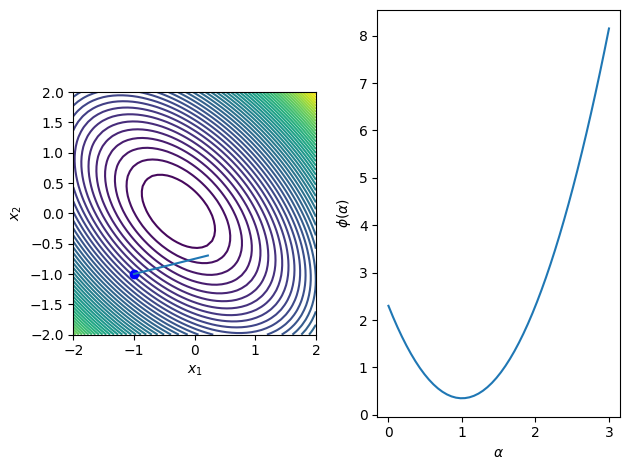

In [4]:
b = np.array([0.5, 0.2])
A = np.array([[2, 1], [1, 2]])

def fquad(x):    
    return 0.5*np.dot(x, np.dot(A, x)) + np.dot(b, x)

x0 = np.array([-1, -1])
p0 = np.array([1, 0.25])

alph = - np.dot(p0, np.dot(A, x0) + b)/np.dot(p0, np.dot(A, p0))

# Plot the merit function with the line search direction normalized
dirs = [p0*alph]
merit_func_plot(fquad, x0, dirs)

## Graphical line search

It can be useful for visualization or for understanding the behavior of line search algorithms to be able to perform a graphical line search.
When the merit function is given by

\begin{equation*}
\phi(\alpha) = f(x + \alpha p)
\end{equation*} 

At the minimizer of $\phi(\alpha)$, $\alpha^{*}$, from first-order conditions we have $\phi'(\alpha^{*}) = 0$ so that 

\begin{equation*}
\phi'(\alpha) = \nabla f(x + \alpha p)^{T} p = 0
\end{equation*}

1. The gradient and the search direction are perpendicular at the exact minimizer
2. Since contour lines are perpendicular to the gradient, graphically the minimum will occur where the contours of $f$ and the direction $p$ are tangent to one another

<img src="line_search_merit_derivative_illustration.png">

## Inexact line search criteria

Thus far, we've looked for exact minimizers of the line search problem

\begin{equation*}
\min_{\alpha} \phi(\alpha).
\end{equation*}

However, in many algorithms it is more efficient to perform an inexact line search, where we find a step length $\alpha$ that satisfies certain line search criteria.
These criteria ensure that the optimization algorithm makes progress towards minimizing the objective function $f(x)$.

What line search criteria should be enforced?
If we just impose that the line search improve the current objective function value, then we could impose

\begin{equation*}
\phi(\alpha) \le \phi(0).
\end{equation*}

This is called a simple decrease criteria.
The simple decrease criteria is not sufficient to ensure that progress is made.

Consider the function $f(x) = x^2$, and the sequence of points 

\begin{equation*}
x_{k} = 1 + \frac{1}{k}
\end{equation*}

Each point $x_{k}$ for $k = 1,2,\ldots$, has a lower function value than the previous one, but the sequence never makes it all the way to the minimizer at $x = 0$.
The step lengths $|x_{k+1} - x_{k}|$ keep getting smaller.

What about requiring a sufficiently long step?
Consider the sequence

\begin{equation*}
x_{k} = (-1)^{k+1}\left(1 + \frac{1}{k}\right)
\end{equation*}

The step lengths are always $> 2$, but never get to $x = 0$.

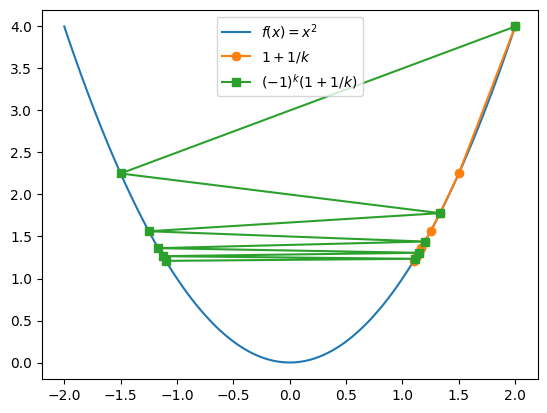

In [5]:
import numpy as np
import matplotlib.pylab as plt

x = np.linspace(-2, 2, 100)

# Create the two sequences
N = 10
x1 = np.zeros(N)
x2 = np.zeros(N)

for k in range(1, N+1):
    x1[k-1] = 1.0 + 1.0/k
    x2[k-1] = (-1.0)**(k+1)*(1.0 + 1.0/k)

plt.plot(x, x**2, label=r'$f(x) = x^2$')
plt.plot(x1, x1**2, marker='o', label=r'$1 + 1/k$')
plt.plot(x2, x2**2, marker='s', label=r'$(-1)^k(1 + 1/k)$')
plt.legend()
plt.show()

## Wolfe conditions

The Wolfe conditions are a set of line search criteria that are enforced at each step in a line search optimization algorithm.

### First Wolfe condition

The first Wolfe condition is also called the sufficient decrease criteria or the Armijo rule and requires that the candidate step length $\alpha$ satisfy

\begin{equation*}
\phi(\alpha) \le \phi(0) + c_1 \alpha \phi'(0)
\end{equation*}

Here $c_{1} \in (0, 1)$ is a constant.
Typical values are $c_{1} =10^{-3}$ to $10^{-4}$, which is not a very stringent value.
This criteria requires that the new function value be less than a linearization of $\phi$ about the current point $\alpha = 0$ with a slope that is $c_1$ times the true slope of the merit function.

### Example

Let's take a look at what happens with the first sequence above for the objective function $f(x) = x^2$.
For these problems $\phi(\alpha) = f(x + \alpha p) = (x + \alpha p)^2$ and $\phi'(\alpha) = 2(x + \alpha p) p$. 
Here we will take $p = -f'(x)/|f'(x)| = - x/|x| = -\text{sign}(x)$ as the search direction.

For the first sequence with $x_{k} = 1 + \dfrac{1}{k}$, the first Wolfe condition is satisfied if

\begin{equation*}
\phi_{k+1} \le \phi_{k} + c_{1} \alpha_{k} \phi_{k}'
\end{equation*}

Here we see that $x_{k} > 0$ so that the search directions are always $p_{k} = -1$.
As a result $\phi_{k}' = -2x_{k}$.
The step length at iteration $k$ is $\alpha_{k} = |x_{k+1} - x_{k}| = \left| \dfrac{1}{k+1} - \dfrac{1}{k}\right| = \dfrac{1}{k(k+1)}$.

The first Wolfe condition is satisfied if
\begin{equation*}
\left(1 + \dfrac{1}{k+1}\right)^2 \le \left(1 + \dfrac{1}{k}\right)^2 - 
c_{1} \dfrac{2}{k(k+1)}\left(1 + \dfrac{1}{k}\right)
\end{equation*}

If $c_{1}$ is small enough, this equation will be satisfied for all $k$. *Check for yourself*.

Now, let's take a look at the second sequence, $x_{k} = (-1)^{k+1}\left(1 + \frac{1}{k}\right)$.

Here we have that the direction $p_{k}$ alternates sign so that $p_{k} = (-1)^{k}$.
The step lengths are 

\begin{equation*}
\alpha_{k} = |x_{k+1} - x_{k}| = \left(1 + \frac{1}{k}\right) + \left(1 + \frac{1}{k+1}\right) = 2 + \frac{k+2}{k(k+1)}
\end{equation*}

The first Wolfe condition is satisfied if

\begin{equation*}
\left(1 + \dfrac{1}{k+1}\right)^2 \le \left(1 + \dfrac{1}{k}\right)^2 - 
2c_{1}\left(2 + \frac{k+2}{k(k+1)}\right)\left(1 + \dfrac{1}{k}\right)
\end{equation*}

This equation will be violated, even for small $c_{1} > 0$.
As a result, the first Wolfe condition will eventually reject this sequence.

## Second Wolfe condition

The second Wolfe condition is designed to ensure that we take sufficiently large steps that make progress towards the minimizer.
The second Wolfe condition is written 

\begin{equation*}
\phi'(\alpha) \ge c_{2} \phi'(0)
\end{equation*}

Note that the slope of the merit function at the origin is negative so that $\phi'(0) < 0$.
The constant $c_{2}$ is chosen so that $c_{2} \in (c_1, 1)$.
Typical values between $0.1$ and $0.9$

You can check for yourself that this criteria eventually rejects steps from the first sequence above.

Step must make sufficient progress - rules out the first sequence
    
## Strong Wolfe conditions
 
The strong Wolfe conditions impose an additional requirement beyond the regular first two Wolfe conditions.
The strong Wolfe conditions require that the absolute slope of the line search function must decrease by a specified fraction below the slope at $\alpha = 0$.
This criteria is written as

\begin{equation*}
|\phi'(\alpha)| \le c_{2} |\phi'(0)|
\end{equation*}

The strong Wolfe conditions are then the combination of the sufficient decrease condition and this stronger criteria on the slope of the merit function, giving

\begin{equation*}
\begin{aligned}
\phi(\alpha) & \le \phi(0) + c_1 \alpha \phi'(0) \\
|\phi'(\alpha)| & \le c_{2} |\phi'(0)|
\end{aligned}
\end{equation*}

The strong Wolfe conditions can be used to prove convergence of line search methods to a local minimizer.
This type of convergence proof is often called global convergence, since it shows that given any (global) starting point, the algorithm will find a minimizer (not necessarily the global minimizer).

This figure illustrates the different intervals for the first, second and strong Wolfe conditions.

<img src="wolfe_conditions.png">

### Example

Find the intervals for the following merit function $\phi(\alpha)$ satisfying the Wolfe conditions

\begin{equation*}
\phi(\alpha) = -\alpha + \alpha(\alpha - 5)(2 - \alpha)^2 
\end{equation*}

The first derivative of $\phi$ is:

\begin{equation*}
\phi'(\alpha) = 4\alpha^3 - 27\alpha^2 + 48\alpha - 21
\end{equation*}

The function value and first derivative are
\begin{equation*}
\phi(0) = 0 \qquad\qquad \phi'(0) = -21
\end{equation*}

The first Wolfe condition (Armijo condition) is
\begin{equation*}
\begin{aligned}
-\alpha + \alpha(\alpha - 5)(2 - \alpha)^2  & \le \phi(0) + c_{1} \alpha \phi'(0) \\
-\alpha + \alpha(\alpha - 5)(2 - \alpha)^2  & \le - 21 c_{1} \alpha \\
\end{aligned}
\end{equation*}

The second Wolfe condition is

\begin{equation*}
\begin{aligned}
4\alpha^3 - 27\alpha^2 + 48\alpha - 21 & \ge c_{2} \phi'(0) \\
4\alpha^3 - 27\alpha^2 + 48\alpha - 21 & \ge - 21 c_{2} \\
\end{aligned}
\end{equation*}



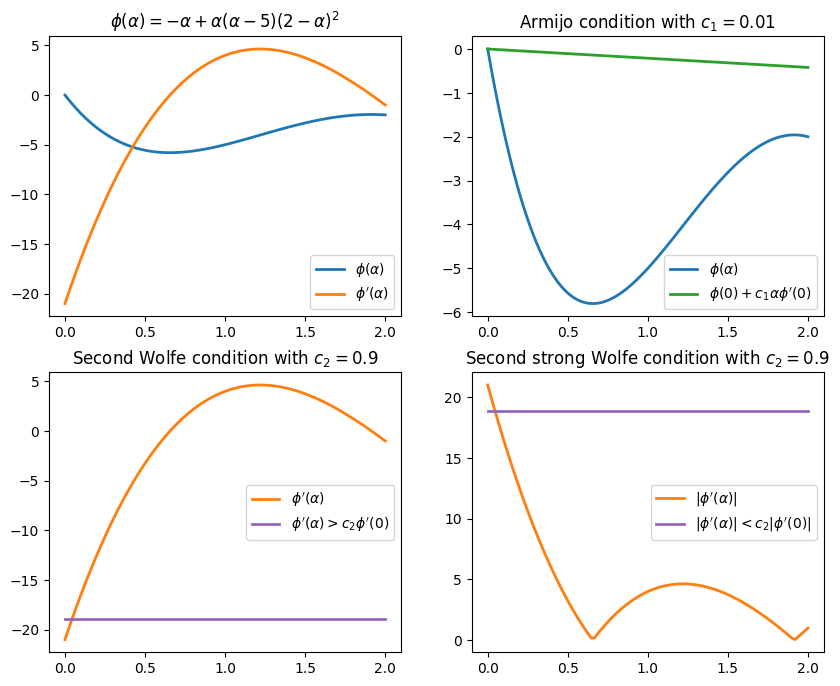

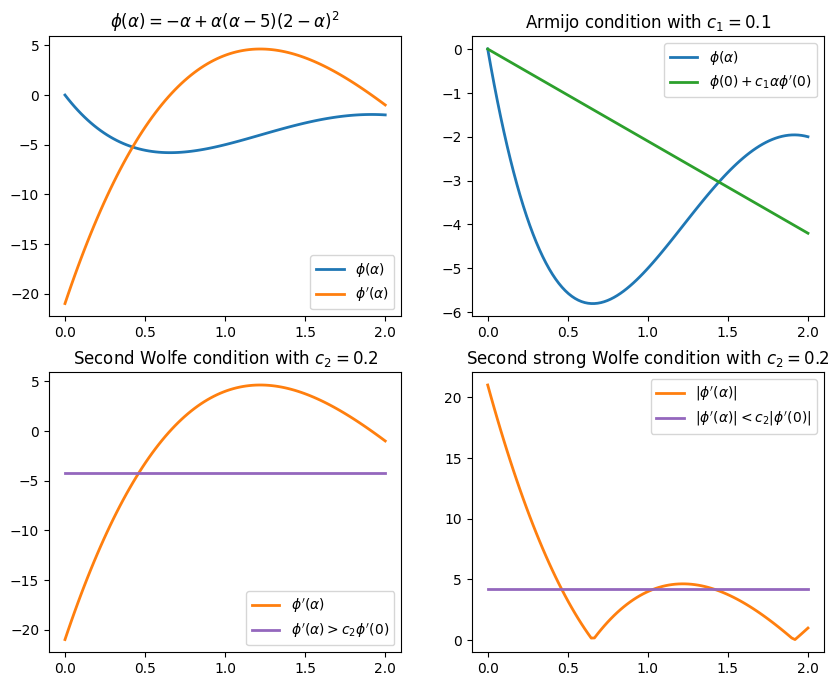

In [6]:
import numpy as np
import matplotlib.pylab as plt 

# Get the default colors from matplotlib
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

def plot_wolfe_conditions(c1, c2):
    a = np.linspace(0, 2, 100)
    
    fig, ax = plt.subplots(2, 2, figsize=(10,8))
    # Plot the line search function and its derivative
    ax[0,0].set_title(r'$\phi(\alpha) = -\alpha + \alpha(\alpha - 5)(2 - \alpha)^2$')
    ax[0,0].plot(a, -a + a*(a -5)*(2 - a)**2, 
                 label=r'$\phi(\alpha)$', color=colors[0], linewidth=2)
    ax[0,0].plot(a, -21 + 48*a - 27*a**2 + 4*a**3, 
                 label=r"$\phi'(\alpha)$", color=colors[1], linewidth=2)
    ax[0,0].legend()

    # Plot the Armijo/sufficient decrease condition
    ax[0,1].set_title(r'Armijo condition with $c_{1} = %g$'%(c1))
    ax[0,1].plot(a, -a + a*(a -5)*(2 - a)**2, label=r'$\phi(\alpha)$', 
                 color=colors[0], linewidth=2)
    ax[0,1].plot(a, -21*c1*a, label=r"$\phi(0) + c_{1} \alpha \phi'(0)$",
                 color=colors[2], linewidth=2)
    ax[0,1].legend()
    
    ax[1,0].set_title(r'Second Wolfe condition with $c_{2} = %g$'%(c2))
    ax[1,0].plot(a, -21 + 48*a - 27*a**2 + 4*a**3, 
        label=r"$\phi'(\alpha)$", color=colors[1], linewidth=2)
    ax[1,0].plot(a, -21*c2*np.ones(a.shape), 
        label=r"$\phi'(\alpha) > c_{2} \phi'(0)$", color=colors[4], linewidth=2)
    ax[1,0].legend()
    
    ax[1,1].set_title(r'Second strong Wolfe condition with $c_{2} = %g$'%(c2))
    ax[1,1].plot(a, np.fabs(-21 + 48*a - 27*a**2 + 4*a**3), label=r"$|\phi'(\alpha)|$", 
                 color=colors[1], linewidth=2)
    ax[1,1].plot(a, 21*c2*np.ones(a.shape), 
                 label=r"$|\phi'(\alpha)| < c_{2} |\phi'(0)|$", 
                 color=colors[4], linewidth=2)
    ax[1,1].legend()

    return

c1 = 0.01
c2 = 0.9
plot_wolfe_conditions(c1, c2)

c1 = 0.1
c2 = 0.2
plot_wolfe_conditions(c1, c2)

plt.show()

## Backtracking line search

The simplest line search criteria is based on the sufficient decrease condition, also called the first Wolfe condition or the Armijo rule. The sufficient decrease condition is given by the following requirement

\begin{equation*}
\phi(\alpha) \le \phi(0) + c_{1} \alpha \phi'(0),
\end{equation*}

where $c_{1}$ is a constant often taken to be a small value between $c_{1} = 10^{-3}$ and $c_{1} = 10^{-4}$.

Since the linear approximation of the merit function will become better as $\alpha \rightarrow 0$, a line search method for the sufficient decrease conditions is guaranteed to converge if the step lengths chosen always decrease.

The backtracking line search works by selecting an initial step length $\alpha = 1$, for instance, and reducing the step by a constant factor $\tau < 1$. It is common to use $\tau = 1/2$. At the $k$-th step of the line search, the line search step will be equal to

\begin{equation*}
\alpha_{k} = \tau^{k-1} \alpha_{1},
\end{equation*}

for $k = 2,3,\ldots$. 

More sophisticated methods use quadratic or cubic interpolations of the merit function to estimate the best approximation of the new line search step. Note that if a line search step fails, then it violates the sufficient decrease condition such that

\begin{equation*}
\phi(\alpha_{k}) > \phi(0) + c_{1} \alpha_{k} \phi'(0).
\end{equation*}

This condition can be used to establish that the line search step length obtained from quadratic or cubic interpolation methods always decreases, thereby establishing that the line search converges. 

The backtracking line search works in the follwing manner:

1. Given $\alpha_{1}$ and backtracking fraction $\tau \in (0, 1)$, set $k = 1$
2. Evaluate $\phi(\alpha_{k})$
    1. If $\phi(\alpha_{k}) \le \phi(0) + c_{1}\alpha_{k} \phi'(0)$, set $\alpha = \alpha_{k}$ and exit.
3. Set $\alpha_{k+1} = \tau \alpha_{k}$
4. Set $k = k + 1$ and go to step 2

One dimensional problem
Sufficient decrease failed with alpha =  1.00000000e+00
phi(alpha) =                             2.81875000e+01
phi0 + c1*alpha*dphi0 =                 -1.15500000e-01
Rosenbrock
Sufficient decrease failed with alpha =  1.00000000e+00
phi(alpha) =                             8.76556747e+01
phi0 + c1*alpha*dphi0 =                  2.87728085e+01
Griewank
Sufficient decrease failed with alpha =  1.00000000e+00
phi(alpha) =                             7.58933812e-01
phi0 + c1*alpha*dphi0 =                  2.47763932e-01
Sufficient decrease failed with alpha =  5.00000000e-01
phi(alpha) =                             5.38043949e-01
phi0 + c1*alpha*dphi0 =                  2.48881966e-01
Sufficient decrease failed with alpha =  2.50000000e-01
phi(alpha) =                             6.27491467e-01
phi0 + c1*alpha*dphi0 =                  2.49440983e-01
Sufficient decrease failed with alpha =  1.25000000e-01
phi(alpha) =                             2.69473792e-01
phi0

0.0625

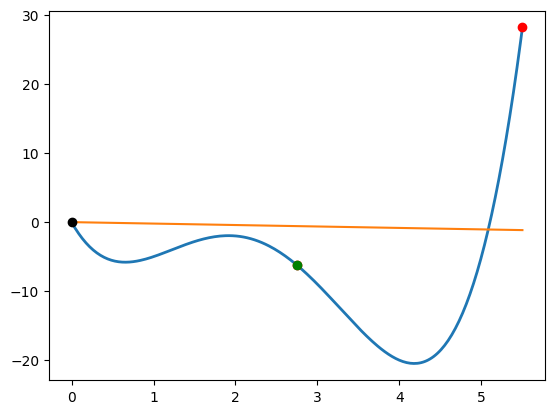

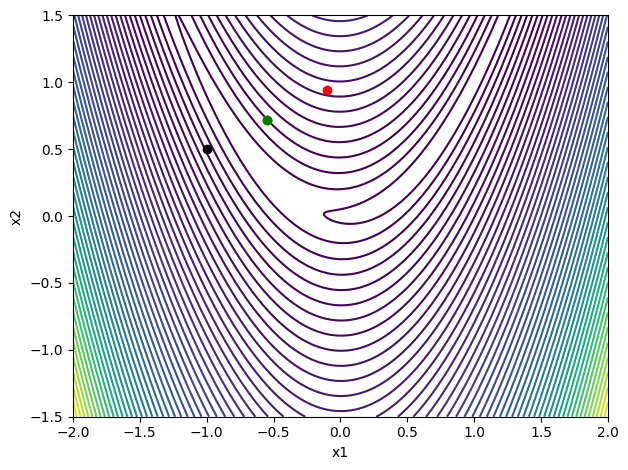

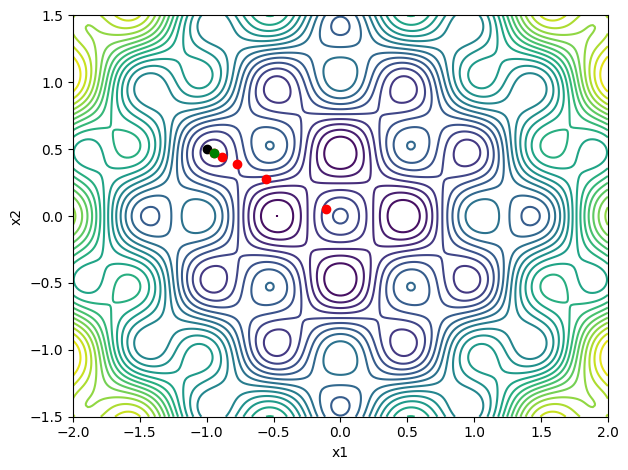

In [7]:
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline

def fonedim(x, linesearch=False, symb='ko'):
    f = -x[0] + x[0]*(x[0] - 5)*(2 - x[0])**2
    if linesearch:
        plt.plot(x[0], f, symb)
    return f

def fonedim_grad(x):
    return np.array([-21 + 48*x[0] - 27*x[0]**2 + 4*x[0]**3])
    
def rosen(x, linesearch=False, symb='ko'):
    """If the linesearch flag is true, plot the point"""
    if linesearch:
        plt.plot([x[0]], [x[1]], symb)
    return (1 - x[0])**2 + 100*(x[1] - x[0]**2)**2

def rosen_grad(x):
    return np.array([-2*(1 - x[0]) - 400*(x[1] - x[0]**2)*x[0], 
                      200*(x[1] - x[0]**2) ])

def griewank(x, linesearch=False, symb='ko'):
    if linesearch:
        plt.plot([x[0]], [x[1]], symb)
    return x[0]**2 + x[1]**2 + np.cos(2*np.pi*x[0])*np.cos(2*np.pi*x[1])

def griewank_grad(x):
    return np.array([2*x[0] - 2*np.pi*np.sin(2*np.pi*x[0])*np.cos(2*np.pi*x[1]),
                     2*x[1] - 2*np.pi*np.cos(2*np.pi*x[0])*np.sin(2*np.pi*x[1])])

def onedim_plot(func, n=250, xhigh=5.0):
    x = np.linspace(0, xhigh, n)
    f = np.zeros(n)
    for i in range(n):
        f[i] = func([x[i]])
    plt.figure()
    plt.plot(x, f, linewidth=2)
    return

def contour_plot(func, n=250, xlow=-2, xhigh=2, ylow=-1.5, yhigh=1.5):
    """Create a contour plot of the function"""
    x = np.linspace(xlow, xhigh, n)
    y = np.linspace(ylow, yhigh, n)
    X, Y = np.meshgrid(x, y)
    f = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            f[i, j] = func([X[i, j], Y[i, j]])

    fig, ax = plt.subplots(1, 1)
    if func == rosen:
        ax.contour(X, Y, f, levels=np.max(f)*np.linspace(0, 1.0, 50)**2)
    else:
        ax.contour(X, Y, f, levels=np.linspace(np.min(f), np.max(f), 25))
    plt.xlabel('x1')
    plt.ylabel('x2')
    ax.set_aspect('equal', 'box')
    fig.tight_layout()    
    
    return
    
def backtrack(func, grad_func, x, p, 
              tau=0.5, alpha=1.0, c1=1e-3, max_iter=100):
    """
    Given the function pointer and the gradient function pointer,
    find a step length alpha that satisfies the sufficient decrease
    conditions.
    """
    
    # Evaluate the function and gradient at the initial point x
    phi0 = func(x, linesearch=True)
    grad0 = grad_func(x)
    
    # Compute the derivative of the merit function at alpha = 0.0
    dphi0 = np.dot(grad0, p)
    
    # Check for a descent direction
    if dphi0 >= 0.0:
        return ValueError('Must provide a descent direction')
    
    for i in range(max_iter):
        # Evaluate the function at the new point
        xp = x + alpha*p
        phi = func(xp, linesearch=True, symb='ro')
        
        # Check the sufficient decrease condition
        if phi < phi0 + c1*alpha*dphi0:
            # Evaluate the function again to illustrate the final point
            func(xp, linesearch=True, symb='go')
            return alpha
        else:
            print('Sufficient decrease failed with alpha = %15.8e'%(alpha))
            print('phi(alpha) =                            %15.8e'%(phi))
            print('phi0 + c1*alpha*dphi0 =                 %15.8e'%(phi0 + c1*alpha*dphi0))
        
        # Set the alpha values and append one to the list
        alpha = tau*alpha
    
    # The line search has failed at this point
    return 0.0

# Plot the one dimensional problem
x = np.array([0])
p = np.array([5.5])
onedim_plot(fonedim, xhigh=5.5)

# Plot the sufficient decrease line on the plot
phi0 = fonedim(x)
dphi0 = np.dot(fonedim_grad(x), p)
xhigh = 5.5
alph = p[0]
c1 = 0.01
plt.plot([0.0, xhigh], [phi0, phi0 + c1*(xhigh/alph)*dphi0])

# Perform a backtracking line search
print('One dimensional problem')
backtrack(fonedim, fonedim_grad, x, p)

# Create a contour plot
contour_plot(rosen)

# Choose an initial point and the gradient direction
x = np.array([-1, 0.5])
p = -rosen_grad(x)
p = p/np.sqrt(np.dot(p, p))

# Perform a backtracking line search
print('Rosenbrock')
backtrack(rosen, rosen_grad, x, p)

# Create a contour plot
contour_plot(griewank)

p = -griewank_grad(x)
p = p/np.sqrt(np.dot(p, p))

# Perform a backtracking line search
print('Griewank')
backtrack(griewank, griewank_grad, x, p)

## Interpolation-based backtracking

Sometimes the performance of a line search procedure can be improved by performing an interpolation of the line search function to obtain a better estimate for the location of the minimum function value.
Care must be excercised, however, to ensure that the interpolated minimum gives reasonable guesses.

A quadratic interpolation can be formed by interpolating between the points $\alpha = 0$, and $\alpha = \alpha_{k}$, using $\phi(0)$, $\phi'(0)$ and $\phi(\alpha_{k})$.
In the case of a quadratic approximation, the line search interpolant is given by $\tilde{\phi}$

\begin{equation*}
\tilde{\phi}(\alpha) = a \alpha^2 + b\alpha + c
\end{equation*}

The coefficients of $\tilde{\phi}(\alpha)$ are

\begin{equation*}
\begin{aligned}
c & = \phi(0) &
b & = \phi'(0) &
a & = \frac{\phi(\alpha_{k}) - \phi'(0)\alpha_{k} - \phi(0)}{\alpha_{k}^2}
\end{aligned}
\end{equation*}

The new estimate is given by:
\begin{equation*}
\alpha_{k+1} = - \frac{b}{2a}
\end{equation*}

This line search step length will be in the interval $\alpha_{k+1} \in [0, \alpha_{k}]$

If the quadratic line search step estimate fails, we can use a more refined cubic estimate.
The cubic fit forms an interpolation between $\alpha = 0$, $\alpha = \alpha_{k-1}$, and $\alpha = \alpha_{k}$, using the function values $\phi(0)$, $\phi'(0)$, $\phi(\alpha_{k})$, and $\phi(\alpha_{k-1})$.

The cubic approximation is given by $\tilde{\phi}$

\begin{equation*}
\tilde{\phi}(\alpha) = a \alpha^3 + b \alpha^2 + \alpha\phi'(0) + \phi(0)
\end{equation*}

The coefficients $a$ and $b$ of the cubic, are given by the solution of the following linear system:

\begin{equation*}
\begin{bmatrix}
\alpha_{k}^3 & \alpha_{k}^2 \\
\alpha_{k-1}^3 & \alpha_{k-1}^2 
\end{bmatrix}
\begin{bmatrix}
a \\ b
\end{bmatrix} = 
\begin{bmatrix} 
\phi(\alpha_{k}) - \phi(0) - \phi'(0)\alpha_{k} \\
\phi(\alpha_{k-1}) - \phi(0) - \phi'(0)\alpha_{k-1} 
\end{bmatrix}
\end{equation*}

The next step length is calculated as:
\begin{equation*}
\alpha_{k+1} = \frac{-b + \sqrt{b^2 - 3a\phi'(0)}}{3 a}
\end{equation*}

The full interpolation-based sufficient decrease line search method is given as follows

1. Given $\alpha_{1}$, set $k = 1$
2. Evaluate $\phi(\alpha_{k})$
    1. If $\phi(\alpha_{k}) \le \phi(0) + c_{1}\alpha_{k}\phi'(0)$, set $\alpha = \alpha_{k}$ and exit
3. If $k == 1$, interpolate using the quadratic interpolation for $\alpha_{k+1}$
4. Else if $k > 1$, interpolate using the cubic interpolation for $\alpha_{k+1}$
5. Check if $\alpha_{k+1}$ is too close to $\alpha_{k}$, or too small:
    1. If $\alpha_{k+1} < 0.05\alpha_{k}$ or $\alpha_{k+1} > 0.95\alpha_{k}$, $\alpha_{k+1} = 0.5\alpha_{k}$
6. Set $k = k + 1$ and go to step 2

One dimensional problem
Sufficient decrease failed with alpha =  1.00000000e+00
phi(alpha) =                             2.81875000e+01
phi0 + c1*alpha*dphi0 =                 -1.15500000e-01
Rosenbrock
Sufficient decrease failed with alpha =  1.00000000e+00
phi(alpha) =                             8.76556747e+01
phi0 + c1*alpha*dphi0 =                  2.87728085e+01
Griewank
Sufficient decrease failed with alpha =  1.00000000e+00
phi(alpha) =                             7.58933812e-01
phi0 + c1*alpha*dphi0 =                  2.47763932e-01
Sufficient decrease failed with alpha =  4.07298091e-01
phi(alpha) =                             7.77242626e-01
phi0 + c1*alpha*dphi0 =                  2.49089254e-01


np.float64(0.09939243773898021)

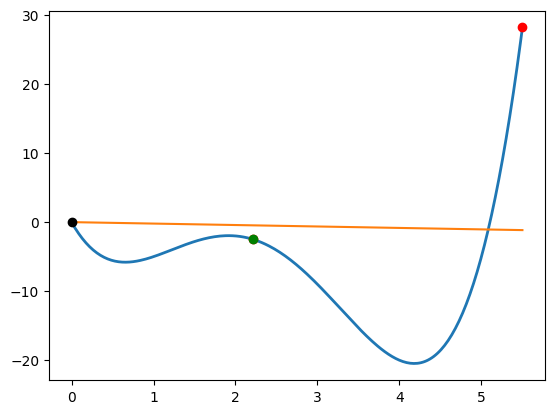

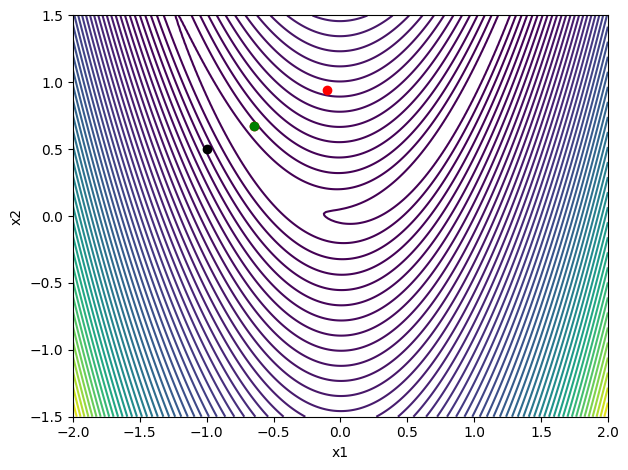

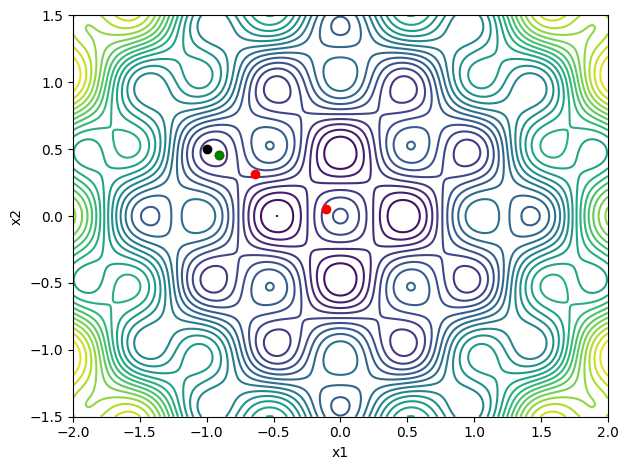

In [8]:
def interp_backtrack(func, grad_func, x, p, 
                     alpha=1.0, c1=1e-3, max_iter=100):
    """
    Given the function pointer and the gradient function pointer,
    find a step length alpha that satisfies the sufficient decrease
    conditions using interpolation-based backtracking.
    """
    
    # Evaluate the function and gradient at the initial point x
    phi0 = func(x, linesearch=True)
    grad0 = grad_func(x)
    
    # Compute the derivative of the merit function at alpha = 0.0
    dphi0 = np.dot(grad0, p)
    
    # Check for a descent direction
    if dphi0 >= 0.0:
        return ValueError('Must provide a descent direction')
    
    phi_prev = 0.0
    alpha_prev = 0.0
    
    for i in range(max_iter):
        # Evaluate the function at the new point
        xp = x + alpha*p
        phi = func(xp, linesearch=True, symb='ro')

        # Check the sufficient decrease condition
        if phi < phi0 + c1*alpha*dphi0:
            # Evaluate the function again to illustrate the final point
            func(xp, linesearch=True, symb='go')
            return alpha
        else:
            print('Sufficient decrease failed with alpha = %15.8e'%(alpha))
            print('phi(alpha) =                            %15.8e'%(phi))
            print('phi0 + c1*alpha*dphi0 =                 %15.8e'%(phi0 + c1*alpha*dphi0))

            if i == 0:
                b = dphi0
                a = (phi - dphi0*alpha - phi0)/alpha**2
                alpha_new = -b/(2.0*a)
            else:
                # Set up the linear system for the cubic interpolant
                A = np.array([[alpha**3, alpha**2], [alpha_prev**3, alpha_prev**2]])
                b = np.array([phi - dphi0*alpha - phi0,
                              phi_prev - dphi0*alpha_prev - phi0])
                
                # Solve the linear system
                ans = np.linalg.solve(A, b)
                a = ans[0]
                b = ans[1]
                
                # Predict the new alpha value
                alpha_new = (-b + np.sqrt(b**2 - 3*a*dphi0))/(3.0*a)
            
            # Record the last alpha and last phi value
            alpha_prev = alpha
            phi_prev = phi
            
            if alpha_new > 0.95*alpha:
                print('Alpha new too large')
                alpha = 0.95*alpha
            elif alpha_new < 0.05*alpha:
                print('Alpha new too small')
                alpha = 0.05*alpha
            else:
                alpha = alpha_new
                
                            
    # The line search has failed at this point
    return 0.0


# Plot the one dimensional problem
x = np.array([0])
p = np.array([5.5])
onedim_plot(fonedim, xhigh=5.5)

# Plot the sufficient decrease line on the plot
phi0 = fonedim(x)
dphi0 = np.dot(fonedim_grad(x), p)
xhigh = 5.5
alph = p[0]
c1 = 0.01
plt.plot([0.0, xhigh], [phi0, phi0 + c1*(xhigh/alph)*dphi0])

# Perform a backtracking line search
print('One dimensional problem')
interp_backtrack(fonedim, fonedim_grad, x, p)

# Create a contour plot
contour_plot(rosen)

# Choose an initial point and the gradient direction
x = np.array([-1, 0.5])
p = -rosen_grad(x)
p = p/np.sqrt(np.dot(p, p))

# Perform a backtracking line search
print('Rosenbrock')
interp_backtrack(rosen, rosen_grad, x, p)

# Create a contour plot
contour_plot(griewank)

p = -griewank_grad(x)
p = p/np.sqrt(np.dot(p, p))

# Perform a backtracking line search
print('Griewank')
interp_backtrack(griewank, griewank_grad, x, p)

## Strong Wolfe condition line search

The strong Wolfe conditions combine both the sufficient decrease condition as well as a curvature condition given as

\begin{equation*}
|\phi'(\alpha)| \le c_{2} |\phi'(0)|.
\end{equation*}

This curvature condition is more challenging to satisfy compared with the sufficient decrease conditions alone.

The following line search algorithm works in two stages: (1) An initial stage in which an interval is found which contains a point that satisfies the strong Wolfe conditions; (2) A second "zoom" phase in which the interval from the first phase is bracketed until a new point is found.

An interval $[0, \alpha]$ will contain a step length that satisfies the strong Wolfe conditions if (1) the sufficient decrease conditions are violated at the point $\alpha$. Or (2), the sufficient decrease condition is satisfied at $\alpha$ and the slope of the merit function satisfies $\phi'(\alpha) > 0$. Try to convince yourself that this is true by sketching merit functions with the line search criteria.

The first phase of the algorithm works by expanding the maximum step length and testing these two criteria. If we find a step length that satisfies the strong Wolfe conditions along the way, then the strong Wolfe condition line search returns the value of the step length.

### Strong Wolfe condition search algorithm

The line search algorithm first begins by setting an initial guess for the line search step $\alpha_{1}$ and

1. Given $\alpha_{1}$, $\alpha_{\max}$, set $\alpha_0 = 0$, $k = 1$
2. Evaluate $\phi(\alpha_{k})$
3. If $\phi(\alpha_{k}) > \phi(0) + c_1\alpha_{k}\phi'(0)$ or ($k > 1$ and $\phi(\alpha_{k}) \ge \phi(\alpha_{k-1})$)
    1. $\alpha = \textbf{zoom}(\alpha_{k-1}, \alpha_{k})$, break
4. Else Evaluate $\phi'(\alpha_{k})$
    1. If $|\phi'(\alpha_{k})| \le c_{2}|\phi'(0)|$ 
        1. $\alpha = \alpha_{k}$, strong Wolfe conditions satisfied, break
5. If $\phi'(\alpha_{k}) \ge 0$
    1. $\alpha = \textbf{zoom}(\alpha_{k}, \alpha_{k-1})$, break
6. Choose $\alpha_{k+1} \in (\alpha_{k}, \alpha_{max})$, $k = k+1$, goto 2

Note the following facts about the algorithm:

* The interval $(\alpha_{k-1}, \alpha_{k})$ contains step lengths satisfying the strong Wolfe condition if any of the following conditions are satisfied:
    1. $\alpha_{k}$ violates the sufficient decrease condition
    2. $\phi'(\alpha_{k}) \ge 0$
    3. $\phi(\alpha_{k}) \ge \phi(\alpha_{k-1})$
* The method used to select $\alpha_{k+1} \in (\alpha_{k}, \alpha_{\max})$, should increase $\alpha_{k+1}$ rapidly to reach $\alpha_{\max}$


### Zoom phase

The zoom phase of the algorithm is designed to find a point in an interval that satisfies the strong Wolfe conditions.

The algorithm can be described as follows:

$\textbf{zoom}(\alpha_{low}, \alpha_{hi}):$

1. Interpolate between $\alpha_{low}$, $\alpha_{hi}$ (with cubic interpolation, for instance) to find $\alpha_{k}$
2. Evaluate $\phi(\alpha_{k})$ 
3. If $\phi(\alpha_{k}) > \phi(0) + c_1 \alpha_{k}\phi'(0)$ or $\phi(\alpha_{k}) \ge \phi(\alpha_{low})$
    1. $\alpha_{hi} = \alpha_{k}$
4. Else:
    1. Evaluate $\phi'(\alpha_{k})$
    2. If $|\phi'(\alpha_{k})| \le c_2 |\phi'(0)|$, set $\alpha = \alpha_{k}$ and return
    3. If $\phi'(\alpha_{k})(\alpha_{hi} - \alpha_{low}) \ge 0$
        1. $\alpha_{hi} = \alpha_{low}$
    4. $\alpha_{low} = \alpha_{k}$
5. $k = k+1$, goto line 1

Notes on the zoom phase of the algorithm:

* $\alpha_{low}$: $\alpha$ for lowest objective value seen thus far satisfying the first Wolfe condition, $\alpha_{hi}$: $\alpha$ the larger objective value
* $\alpha_{hi}$ chosen such that $\phi'(\alpha_{low})(\alpha_{hi} - \alpha_{low}) < 0$

The zoom phase of the algorithm uses two values of $\alpha_{low}$ and $\alpha_{high}$. These are defined such that $\phi(\alpha_{low}) \le \phi(\alpha_{high})$. (Note: it does not refer to the values of $\alpha$ itself.)

The values of $\alpha_{low}$ and $\alpha_{high}$ are also chosen so that (1) the value of $\phi(\alpha_{low})$ is the lowest value of the merit function evaluated so far that satisfies the sufficient decrease condition, and (2) the interval satisfies the property $\phi'(\alpha_{low})(\alpha_{high} - \alpha_{low}) < 0$. This second condition ensures that the interval contains steps satisfying the strong Wolfe conditions.

The zoom function works by finding a new point, $\alpha_{j}$, within the interval between $\alpha_{low}$ and $\alpha_{high}$ and testing whether this point satisfies the strong Wolfe conditions. If the new point $\alpha_{j}$ violates the sufficient decrease conditions or the value of the merit function $\phi(\alpha_{j}) \ge \phi(\alpha_{low})$, then $\alpha_{j}$ becomes the new $\alpha_{high}$. 

If the sufficient decrease condition is satisfied by $\alpha_{j}$, then the curvature condition is checked and if it is satisfied, the line search terminates. Otherwise at this new point, we know that $\alpha_{j}$ is lower than $\alpha_{low}$ and satisfies the sufficient decrease conditions, so $\alpha_{j}$ becomes the new $\alpha_{low}$. The new $\alpha_{high}$ is selected to satisfy the criteria $\phi'(\alpha_{low})(\alpha_{high} - \alpha_{low}) < 0$.

<img src="zoom_function.png">

### Cubic line search for the strong Wolfe conditions

As the first step in the zoom function, we have to pick a new $\alpha_{k}$ between $\alpha_{hi}$ and $\alpha_{low}$. 
A simple first approach is to use bi-section of the interval so that $\alpha_{k} = \frac{1}{2}(\alpha_{hi} + \alpha_{low})$. This bi-section approach is useful for checking that the line search and zoom functions are working, but better performance can be achieved if a cubic interpolation is used, as illustrated in the code below.

The cubic interpolation can be found as

\begin{equation*}
\alpha = \alpha_{2} - (\alpha_{2} - \alpha_{1})\left(\frac{\phi'(\alpha_{2}) + d_2 - d_1}{\phi'(\alpha_{2}) - \phi'(\alpha_{1}) + 2d_2} \right)
\end{equation*}
  
Where $d_{1}$ and $d_{2}$ are defined as follows:

\begin{equation*}
\begin{aligned}
d_{1} & = \phi'(\alpha_{1}) + \phi'(\alpha_{2}) - 3\left(\frac{\phi(\alpha_1) - \phi(\alpha_2)}{\alpha_{1} - \alpha_2}\right) \\
d_{2} & = \text{sign}(\alpha_2 - \alpha_1)\sqrt{ d_1^2 - \phi'(\alpha_{1})\phi'(\alpha_2)} \\
\end{aligned}
\end{equation*}


Sufficient decrease conditions violated: interval found
Zoom: Curvature condition violated
Zoom: Wolfe conditions satisfied
Slope condition violated; interval found
Zoom: Curvature condition violated
Zoom: Wolfe conditions satisfied


1.75

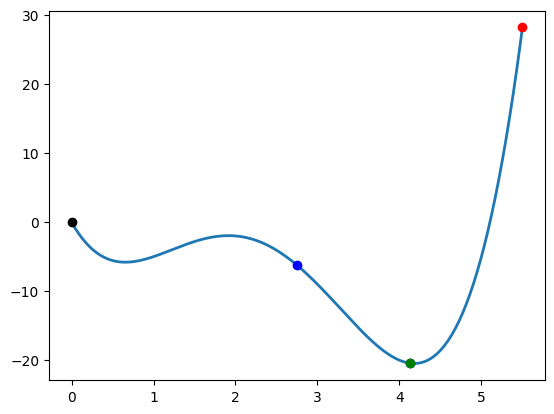

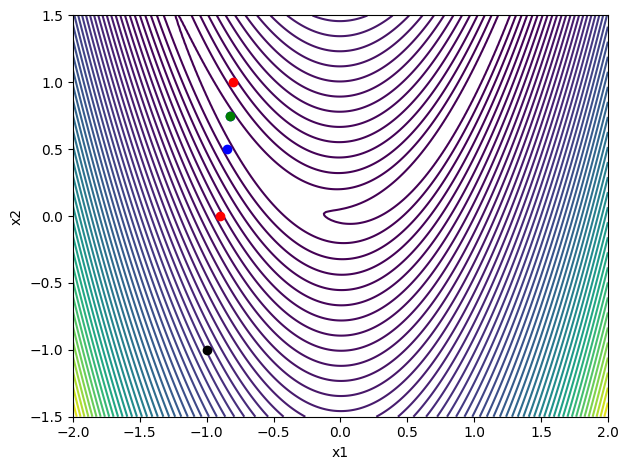

In [9]:
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline

def strong_wolfe(func, grad_func, x, pk, c1=1e-3, c2=0.9,
                 alpha=1.0, alpha_max=100.0, max_iters=100, 
                 verbose=False):
    """
    Strong Wolfe condition line search method 

    Input:
    func:      the function pointer
    grad_func: the gradien function pointer
    x:         the design variables
    p:         the search direction
    alpha:     the initial estimate for the step length
    alpha_max: the maximum value of alpha 

    returns:
    alpha:     the step length satisfying the strong Wolfe conditions
    """
    
    # Compute the function and the gradient at alpha = 0
    fk = func(x, linesearch=True)
    gk = grad_func(x)

    # Compute the dot product of the gradient with the search
    # direction to evaluate the derivative of the merit function
    proj_gk = np.dot(gk, pk)

    # Store the old value of the objective
    fj_old = fk
    proj_gj_old = proj_gk
    alpha_old = 0.0

    for j in range(max_iters):
        # Evaluate the merit function
        fj = func(x + alpha*pk, linesearch=True, symb='ro')

        # Evaluate the gradient at the new point
        gj = grad_func(x + alpha*pk)
        proj_gj = np.dot(gj, pk)

        # Check if either the sufficient decrease condition is
        # violated or the objective increased
        if (fj > fk + c1*alpha*proj_gk or
            (j > 0 and fj > fj_old)):
            if verbose:
                print('Sufficient decrease conditions violated: interval found')
            # Zoom and return
            return zoom(func, grad_func, fj_old, proj_gj_old, alpha_old, 
                        fj, proj_gj, alpha,
                        x, fk, gk, pk, c1=c1, c2=c2, verbose=verbose)

        # Check if the strong Wolfe conditions are satisfied
        if np.fabs(proj_gj) <= c2*np.fabs(proj_gk):
            if verbose:
                print('Strong Wolfe alpha found directly')
            func(x + alpha*pk, linesearch=True, symb='go')
            return alpha

        # If the curvature condition is violat
        if proj_gj >= 0.0:
            if verbose:
                print('Slope condition violated; interval found')
            return zoom(func, grad_func, fj, proj_gj, alpha, 
                        fj_old, proj_gj_old, alpha_old,
                        x, fk, gk, pk, c1=c1, c2=c2, verbose=verbose)

        # Record the old values of alpha and fj
        fj_old = fj
        proj_gj_old = proj_gj
        alpha_old = alpha

        # Pick a new value for alpha
        alpha = min(2.0*alpha, alpha_max)

        if alpha >= alpha_max:
            if verbose:
                print('Line search failed here')
            return None

    if verbose:
        print('Line search unsuccessful')
    return alpha

def zoom(func, grad_func, f_low, proj_low, alpha_low, 
         f_high, proj_high, alpha_high,
         x, fk, gk, pk, c1=1e-3, c2=0.9, max_iters=100, verbose=False):
    """
    Zoom function: Locate a value between alpha_low and alpha_high
    that satisfies the strong Wolfe conditions. Remember:
    alpha_low/alpha_high are step lengths yielding the
    lowest/higher values of the merit function. 

    input:
    f_low:      the value of f(x) at alpha_low
    proj_low:   the value of the derivative of phi at alpha_low
    alpha_low:  the value of the step at alpha_low
    f_high:     the value of f(x) at alpha_high
    proj_high:  the value of the derivative of phi at alpha_high
    alpha_high: the value of the step at alpha_high
    x:          the value of the design variables at alpha = 0
    fk:         the value of the function at alpha = 0
    gk:         the gradient of the function at alpha = 0
    pk:         the line search direction

    returns:
    alpha:   a step length satisfying the strong Wolfe conditions
    """

    proj_gk = np.dot(pk, gk)

    for j in range(max_iters):
        # Pick an alpha value using cubic interpolation
        # alpha_j = cubic_interp(alpha_low, f_low, proj_low,
        #                        alpha_high, f_high, proj_high)

        # Pick an alpha value by bisecting the interval
        alpha_j = 0.5*(alpha_high + alpha_low)

        # Evaluate the merit function
        fj = func(x + alpha_j*pk, linesearch=True, symb='bo')

        # Check if the sufficient decrease condition is violated
        if fj > fk + c1*alpha_j*proj_gk or fj >= f_low:
            if verbose:
                print('Zoom: Sufficient decrease conditions violated')
            alpha_high = alpha_j
            f_high = fj

            # We need the derivative here for proj_high
            gj = grad_func(x + alpha_j*pk)
            proj_high = np.dot(gj, pk)
        else:
            # Evaluate the gradient of the function and the
            # derivative of the merit function
            gj = grad_func(x + alpha_j*pk)
            proj_gj = np.dot(gj, pk)

            # Return alpha, the strong Wolfe conditions are
            # satisfied
            if np.fabs(proj_gj) <= c2*np.fabs(proj_gk):
                if verbose:
                    print('Zoom: Wolfe conditions satisfied')
                func(x + alpha_j*pk, linesearch=True, symb='go')
                return alpha_j
            elif verbose:
                 print('Zoom: Curvature condition violated')

            # Make sure that we have the intervals right
            if proj_gj*(alpha_high - alpha_low) >= 0.0:
                # Swap alpha high/alpha low
                alpha_high = alpha_low
                proj_high = proj_low
                f_high = f_low

            # Swap alpha low/alpha j
            alpha_low = alpha_j
            proj_low = proj_gj
            f_low = fj

    return alpha_j

def cubic_interp(self, x0, m0, dm0, x1, m1, dm1, verbose=False):
    """
    Return an x in the interval (x0, x1) that minimizes a cubic
    interpolant between two points with both function and
    derivative values.

    This method does not assume that x0 > x1. If the solution is
    not in the interval, the function returns the mid-point.
    """

    # Compute d1
    d1 = dm0 + dm1 - 3*(m0 - m1)/(x0 - x1)

    # Check that the square root will be real in the
    # expression for d2
    if (d1**2 - dm0*dm1) < 0.0:
        if verbose:
            print('Cubic interpolation fail')
        return 0.5*(x0 + x1)

    # Compute d2
    d2 = np.sign(x1 - x0)*np.sqrt(d1**2 - dm0*dm1)

    # Evaluate the new interpolation point
    x = x1 - (x1 - x0)*(dm1 + d2 - d1)/(dm1 - dm0 + 2*d2)

    # If the new point is outside the interval, return
    # the mid point
    if x1 > x0 and (x > x1 or x < x0):
        return 0.5*(x0 + x1)
    elif x0 > x1 and (x > x0 or x < x1):
        return 0.5*(x0 + x1)

    return x

# Plot the one dimensional problem
x = np.array([0])
p = np.array([5.5])
onedim_plot(fonedim, xhigh=5.5)

# Perform a backtracking line search
strong_wolfe(fonedim, fonedim_grad, x, p, c2=0.1, verbose=True)

# Choose an initial point and the gradient direction
x = np.array([-1, -1])
# p = -rosen_grad(x)
# p = *p/np.sqrt(np.dot(p, p))
p = np.array([0.1, 1])

# Create a contour plot
contour_plot(rosen)

# Perform a backtracking line search
strong_wolfe(rosen, rosen_grad, x, p, c2=0.1, verbose=True)